# <font color="brown">Bagging and Boosting Case Study </font>

## <font color = "brown">Problem Statement </font>
Build a model to predict the price of a house based on the data shared, and compare how different ensemble techniques, bagging and boosting, perform against each other and against a single tree, both with default settings and after hyperparameter tuning.

## <font color = "brown">Data Dictionary </font>
* price: Price of house
* area: Area of house
* bedrooms: Number of bedrooms
* bathrooms: Number of bathrooms
* stories: Number of floors
* mainroad: Is the property situated on the main road?
* guestroom: Does the house have guest room?
* basement: Does the house have basement?
* hotwaterheating: Does the house have hot water heating?
* airconditioning: Does the house have air conditioning?
* parking: Number of parking available
* prefarea: Is the property in the preffered area?
* furnishingstatus: Type of furnishing of the house

### <font color="blue"> Importing the libraries required

In [105]:
#%pip install xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, root_mean_squared_error
from scipy.stats import randint, uniform

%matplotlib inline

### <font color="blue"> Reading file and understanding the data

In [107]:
data = pd.read_csv("Housing.csv")

In [108]:
#Creating a copy of the data
df = data.copy()

**Let us check the shape of the data**

In [110]:
df.shape

(22932, 13)

The data has 22,932 observations and 13 features.

**Checking the data types**

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22932 entries, 0 to 22931
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             22932 non-null  int64 
 1   area              22932 non-null  int64 
 2   bedrooms          22932 non-null  int64 
 3   bathrooms         22932 non-null  int64 
 4   stories           22932 non-null  int64 
 5   mainroad          22932 non-null  object
 6   guestroom         22932 non-null  object
 7   basement          22932 non-null  object
 8   hotwaterheating   22932 non-null  object
 9   airconditioning   22932 non-null  object
 10  parking           22932 non-null  int64 
 11  prefarea          22932 non-null  object
 12  furnishingstatus  22932 non-null  object
dtypes: int64(6), object(7)
memory usage: 2.3+ MB


6 columns are numeric and 7 columns are categorical (object type).

### <font color="blue"> Missing Value Check

In [116]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

There are no missing values in the data.

### <font color="blue"> Checking Duplicates

In [119]:
df.duplicated().sum()

0

There are no duplicate rows in the data.

## <font color="brown"> Why Ensemble Methods?

A single Decision Tree is easy to interpret, but it tends to either underfit (if kept shallow) or overfit (if grown deep), we saw this clearly in the Decision Trees case study. **Ensemble methods** combine many trees together to build a model that is more accurate and more stable than any single tree.

There are two very different ways to build a tree ensemble:

* **Bagging** (Bootstrap Aggregating) trains many trees *independently, in parallel*, each on a random bootstrap sample (random rows, with replacement) of the training data, and averages their predictions. Since the trees are trained independently of each other, bagging mainly reduces **variance** (overfitting). The original Bagging technique only randomized rows, sklearn's `BaggingRegressor` also lets us randomize columns per tree via `max_features`, but that's a coarser, optional setting, not something it does by default. **Random Forest** was introduced later specifically to build on bagging with a finer-grained kind of column randomization: instead of picking one random subset of features per tree, it picks a new random subset *at every single split*, which decorrelates the trees far more effectively.
* **Boosting** trains trees *sequentially*, where each new tree focuses specifically on correcting the mistakes of the trees built before it. This mainly reduces **bias** (underfitting), but if left unchecked (too many trees, too much depth) it can start overfitting too.

We'll build one bagging-family model, one Random Forest, and three boosting-family models (AdaBoost, Gradient Boosting, and XGBoost). For each one, we'll first look at its performance with **default** settings, and then use **`RandomizedSearchCV`** (the same idea as the `GridSearchCV` we used in the Decision Trees case study, but sampling a fixed number of random combinations instead of trying every single one, much faster when there are several continuous hyperparameters to search over) to tune it.

Since every model here is tree-based, we don't need to scale the features or log-transform the target the way we did for Linear Regression and Regularization, trees split on thresholds one feature at a time, not on linear combinations of features, so they aren't sensitive to the scale of the inputs.

## <font color="brown"> Data Preparation

Splitting the data into independent and dependent variables.

In [124]:
X = df.drop('price', axis=1)
y = df['price']

Creating the dummy variables for the categorical columns.

In [126]:
X = pd.get_dummies(
    data=X,
    columns=X.select_dtypes(include='object').columns.to_list(),
    drop_first=True,
    dtype=int,
)

X.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,5359,3,1,1,2,1,0,0,0,0,0,1,0
1,3047,3,1,2,0,1,0,1,0,0,1,0,1
2,6462,3,1,4,0,1,0,0,0,1,1,1,0
3,6999,2,3,3,0,1,0,0,0,0,0,0,0
4,2078,3,1,2,2,1,0,0,0,0,0,1,0


Splitting the data into train and test. 70% of the data goes to train and 30% goes to test.

In [128]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

## <font color="brown"> Model 1: Bagging Regressor (Default)

Bagging Regressor trains 100 Decision Tree Regressors, each on a different bootstrap sample of the training data, and averages their predictions.

In [131]:
bag = BaggingRegressor(n_estimators=100, random_state=1)
bag.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",1
,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeRegressor`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


Predicting on the train and test set using the model created.

In [133]:
train_pred_bag = bag.predict(X_train)
test_pred_bag = bag.predict(X_test)

### <font color="blue"> Model 1 Metrics (Default)

In [135]:
train_r2_bag = r2_score(y_true=y_train, y_pred=train_pred_bag)
test_r2_bag = r2_score(y_true=y_test, y_pred=test_pred_bag)

train_rmse_bag = root_mean_squared_error(y_true=y_train, y_pred=train_pred_bag)
test_rmse_bag = root_mean_squared_error(y_true=y_test, y_pred=test_pred_bag)

print("Train R2:", train_r2_bag, " Test R2:", test_r2_bag)
print("Train RMSE:", train_rmse_bag, " Test RMSE:", test_rmse_bag)

Train R2: 0.9650981234889455  Test R2: 0.7542745585939177
Train RMSE: 233083.35314755538  Test RMSE: 613780.824582357


**Bagging gets an excellent R2 on train but drops noticeably on test. Averaging many deep, fully-grown trees smooths out some noise, but since every tree is still allowed to grow fully, the ensemble as a whole still overfits.**

### <font color="blue"> Model 1: Bagging Regressor (Tuned with RandomizedSearchCV)

The default Bagging model overfits because its underlying trees have no depth limit. We'll search over the number of trees, how much of the data and how many features each tree sees, and, crucially, how deep each tree is allowed to grow (`estimator__max_depth`).

In [139]:
bag_param_dist = {
    'n_estimators': randint(50, 300),
    'max_samples': uniform(0.5, 0.5),
    'max_features': uniform(0.5, 0.5),
    'estimator__max_depth': randint(3, 15),
}

bag_search = RandomizedSearchCV(
    BaggingRegressor(estimator=DecisionTreeRegressor(random_state=1), random_state=1),
    param_distributions=bag_param_dist,
    n_iter=20,
    cv=3,
    scoring='r2',
    random_state=1,
    n_jobs=-1,
)
bag_search.fit(X_train, y_train)

print("Best parameters found:", bag_search.best_params_)

Best parameters found: {'estimator__max_depth': 14, 'max_features': 0.9995202576620723, 'max_samples': 0.618044488475988, 'n_estimators': 179}


Building the final Bagging Regressor model using the best parameters found.

In [141]:
bag_tuned = bag_search.best_estimator_
bag_tuned.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeRegressor`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeR...andom_state=1)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",179
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.618044488475988
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",0.9995202576620723
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",1
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


Predicting on the train and test set using the tuned model.

In [143]:
train_pred_bag_tuned = bag_tuned.predict(X_train)
test_pred_bag_tuned = bag_tuned.predict(X_test)

#### <font color="blue"> Model 1 Metrics (Tuned)

In [145]:
train_r2_bag_tuned = r2_score(y_true=y_train, y_pred=train_pred_bag_tuned)
test_r2_bag_tuned = r2_score(y_true=y_test, y_pred=test_pred_bag_tuned)

train_rmse_bag_tuned = root_mean_squared_error(y_true=y_train, y_pred=train_pred_bag_tuned)
test_rmse_bag_tuned = root_mean_squared_error(y_true=y_test, y_pred=test_pred_bag_tuned)

print("Train R2:", train_r2_bag_tuned, " Test R2:", test_r2_bag_tuned)
print("Train RMSE:", train_rmse_bag_tuned, " Test RMSE:", test_rmse_bag_tuned)

Train R2: 0.887845104993764  Test R2: 0.772072395075808
Train RMSE: 417826.5038967539  Test RMSE: 591135.0598359829


**Capping the tree depth closes most of the train-test gap we saw in the default model, and test R2 holds steady or improves slightly. A handful of shallower, better-chosen trees generalise just as well as a hundred fully-grown ones.**

## <font color="brown"> Model 2: Random Forest Regressor (Default)

Bagging (above) can optionally randomize which columns each *tree* sees, but only once, when that tree is built. Random Forest goes further: at *every single split* inside every tree, it forces the tree to pick from only a random subset of features, rather than considering all of them. This happens repeatedly throughout each tree's growth, not just once, which decorrelates the trees far more than Bagging's coarser, tree-level randomization.

In [149]:
rf = RandomForestRegressor(n_estimators=100, random_state=1)
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of

Predicting on the train and test set using the model created.

In [151]:
train_pred_rf = rf.predict(X_train)
test_pred_rf = rf.predict(X_test)

### <font color="blue"> Model 2 Metrics (Default)

In [153]:
train_r2_rf = r2_score(y_true=y_train, y_pred=train_pred_rf)
test_r2_rf = r2_score(y_true=y_test, y_pred=test_pred_rf)

train_rmse_rf = root_mean_squared_error(y_true=y_train, y_pred=train_pred_rf)
test_rmse_rf = root_mean_squared_error(y_true=y_test, y_pred=test_pred_rf)

print("Train R2:", train_r2_rf, " Test R2:", test_r2_rf)
print("Train RMSE:", train_rmse_rf, " Test RMSE:", test_rmse_rf)

Train R2: 0.9651108217198983  Test R2: 0.7540753017094566
Train RMSE: 233040.94832863193  Test RMSE: 614029.6292465191


**Random Forest performs almost identically to plain Bagging here. With default settings, its trees are also grown fully, so it shows the same kind of train-test gap.**

### <font color="blue"> Model 2: Random Forest Regressor (Tuned with RandomizedSearchCV)

We'll search over the number of trees, how deep each one can grow, the minimum samples required in a leaf, and how many features are considered at each split.

In [157]:
rf_param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 20),
    'min_samples_leaf': randint(1, 20),
    'max_features': [1.0, 'sqrt', 'log2'],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=1),
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=3,
    scoring='r2',
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)

print("Best parameters found:", rf_search.best_params_)

Best parameters found: {'max_depth': 16, 'max_features': 1.0, 'min_samples_leaf': 7, 'n_estimators': 75}


Building the final Random Forest Regressor model using the best parameters found.

In [159]:
rf_tuned = rf_search.best_estimator_
rf_tuned.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",75
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",16
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",7
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of th

Predicting on the train and test set using the tuned model.

In [161]:
train_pred_rf_tuned = rf_tuned.predict(X_train)
test_pred_rf_tuned = rf_tuned.predict(X_test)

#### <font color="blue"> Model 2 Metrics (Tuned)

In [163]:
train_r2_rf_tuned = r2_score(y_true=y_train, y_pred=train_pred_rf_tuned)
test_r2_rf_tuned = r2_score(y_true=y_test, y_pred=test_pred_rf_tuned)

train_rmse_rf_tuned = root_mean_squared_error(y_true=y_train, y_pred=train_pred_rf_tuned)
test_rmse_rf_tuned = root_mean_squared_error(y_true=y_test, y_pred=test_pred_rf_tuned)

print("Train R2:", train_r2_rf_tuned, " Test R2:", test_r2_rf_tuned)
print("Train RMSE:", train_rmse_rf_tuned, " Test RMSE:", test_rmse_rf_tuned)

Train R2: 0.83976462070245  Test R2: 0.769637795767222
Train RMSE: 499420.16617231665  Test RMSE: 594283.7663519674


**Just like tuned Bagging, tuned Random Forest closes most of its train-test gap while keeping test R2 around the same level, or a little better, than the default model.**

## <font color="brown"> Bagging vs Boosting

Models 1 and 2 above (Bagging, Random Forest) are both from the **bagging family**. Before we move on to **boosting** (Models 3–5), here's a direct comparison of what's different about how the two families are built, *before any boosting has even started*:

| | Bagging (Models 1–2) | Boosting (Models 3–5) |
|---|---|---|
| **How trees are trained** | Independently, in parallel, each tree has no idea what the others are doing | Sequentially, one at a time, each new tree is built specifically to fix the errors left over by all the trees before it |
| **What each tree sees** | A random bootstrap sample of the *rows* (and optionally a random subset of columns) | Every tree typically sees all the rows, but rows/errors that were predicted badly are given *more weight* (or are the direct target, for Gradient Boosting/XGBoost) |
| **How predictions are combined** | A simple average (or majority vote) of all trees, every tree counts equally | A weighted sum of all trees, added together one at a time |
| **What it mainly fixes** | **Variance** (overfitting), many overfit trees average out to something more stable | **Bias** (underfitting), each tree specifically targets what the ensemble is still getting wrong |
| **Typical base tree** | Deep, low-bias, high-variance trees | Shallow, high-bias, low-variance trees ("weak learners") |
| **Main risk** | Can still overfit if every tree is fully grown (we saw this with the default Bagging/Random Forest models above) | Can overfit if given too many rounds or too much depth, since it keeps chasing smaller and smaller errors |

With that contrast in mind, let's build the three boosting models.

## <font color="brown"> Model 3: AdaBoost Regressor (Default)

AdaBoost builds trees sequentially: after each tree, it increases the weight of the training points that were predicted poorly, so the next tree pays more attention to them. Each tree used by AdaBoost is typically shallow, a *weak learner*.

In [167]:
ada = AdaBoostRegressor(n_estimators=100, random_state=1)
ada.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",1
,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
Name,Type,Value
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeRegressor,DecisionTreeR...r(max_depth=3)
estimator_errors_ estimator_errors_: ndarray of floatsRegression error for each estimator in the boosted ensemble.,"ndarray[float64](100,)","[0.18,0.23,0.23,...,0.46,0.46,0.41]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](100,)","[1.53,1.2 ,1.21,...,0.16,0.17,0.35]"
estimators_ estimators_: list of regressorsThe collection of fitted sub-estimators.,list,"[DecisionTreeR...te=1791095845), DecisionTreeR...te=1221370249), DecisionTreeR...ate=500896417), DecisionTreeR...ate=958122221), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](13,)","[0.6 ,0.03,0.09,...,0.02,0. ,0.01]"


Predicting on the train and test set using the model created.

In [169]:
train_pred_ada = ada.predict(X_train)
test_pred_ada = ada.predict(X_test)

### <font color="blue"> Model 3 Metrics (Default)

In [171]:
train_r2_ada = r2_score(y_true=y_train, y_pred=train_pred_ada)
test_r2_ada = r2_score(y_true=y_test, y_pred=test_pred_ada)

train_rmse_ada = root_mean_squared_error(y_true=y_train, y_pred=train_pred_ada)
test_rmse_ada = root_mean_squared_error(y_true=y_test, y_pred=test_pred_ada)

print("Train R2:", train_r2_ada, " Test R2:", test_r2_ada)
print("Train RMSE:", train_rmse_ada, " Test RMSE:", test_rmse_ada)

Train R2: 0.7499053335247092  Test R2: 0.7460266050906552
Train RMSE: 623934.6195219895  Test RMSE: 623996.805736178


**AdaBoost's default weak learners aren't expressive enough to capture this data well, it is underfitting rather than overfitting. Its train and test R2 are close to each other, but both are lower than the other models.**

### <font color="blue"> Model 3: AdaBoost Regressor (Tuned with RandomizedSearchCV)

Since the default model is underfitting, we'll let the search consider deeper base trees (`estimator__max_depth`) as well as the number of boosting rounds and the learning rate, which controls how much each new tree corrects the previous ensemble's mistakes.

In [175]:
ada_param_dist = {
    'n_estimators': randint(50, 300),
    'learning_rate': uniform(0.01, 1.0),
    'estimator__max_depth': randint(1, 10),
}

ada_search = RandomizedSearchCV(
    AdaBoostRegressor(estimator=DecisionTreeRegressor(random_state=1), random_state=1),
    param_distributions=ada_param_dist,
    n_iter=20,
    cv=3,
    scoring='r2',
    random_state=1,
    n_jobs=-1,
)
ada_search.fit(X_train, y_train)

print("Best parameters found:", ada_search.best_params_)

Best parameters found: {'estimator__max_depth': 9, 'learning_rate': 0.47923852643814313, 'n_estimators': 245}


Building the final AdaBoost Regressor model using the best parameters found.

In [177]:
ada_tuned = ada_search.best_estimator_
ada_tuned.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeR...andom_state=1)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",245
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.47923852643814313
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",1
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
Name,Type,Value
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeRegressor,DecisionTreeR...andom_state=1)
estimator_errors_ estimator_errors_: ndarray of floatsRegression error for each estimator in the boosted ensemble.,"ndarray[float64](245,)","[0.18,0.2 ,0.18,...,0.25,0.22,0.28]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](245,)","[0.73,0.66,0.73,...,0.52,0.59,0.44]"
estimators_ estimators_: list of regressorsThe collection of fitted sub-estimators.,list,"[DecisionTreeR...te=1791095845), DecisionTreeR...te=1221370249), DecisionTreeR...ate=500896417), DecisionTreeR...ate=958122221), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](13,)","[0.59,0.04,0.05,...,0.03,0.02,0.02]"


Predicting on the train and test set using the tuned model.

In [179]:
train_pred_ada_tuned = ada_tuned.predict(X_train)
test_pred_ada_tuned = ada_tuned.predict(X_test)

#### <font color="blue"> Model 3 Metrics (Tuned)

In [181]:
train_r2_ada_tuned = r2_score(y_true=y_train, y_pred=train_pred_ada_tuned)
test_r2_ada_tuned = r2_score(y_true=y_test, y_pred=test_pred_ada_tuned)

train_rmse_ada_tuned = root_mean_squared_error(y_true=y_train, y_pred=train_pred_ada_tuned)
test_rmse_ada_tuned = root_mean_squared_error(y_true=y_test, y_pred=test_pred_ada_tuned)

print("Train R2:", train_r2_ada_tuned, " Test R2:", test_r2_ada_tuned)
print("Train RMSE:", train_rmse_ada_tuned, " Test RMSE:", test_rmse_ada_tuned)

Train R2: 0.8390144593648887  Test R2: 0.772054600779639
Train RMSE: 500587.84910731314  Test RMSE: 591158.1343272034


**Allowing deeper base trees gives AdaBoost noticeably more room to fit the data, both train and test R2 improve substantially over the default, closing much of the gap with the other ensembles.**

## <font color="brown"> Model 4: Gradient Boosting Regressor (Default)

Gradient Boosting also builds trees sequentially, but instead of reweighting data points, each new tree is trained to directly predict the *residual errors* left over by the previous trees.

In [185]:
gb = GradientBoostingRegressor(n_estimators=100, random_state=1)
gb.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",1
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)

Predicting on the train and test set using the model created.

In [187]:
train_pred_gb = gb.predict(X_train)
test_pred_gb = gb.predict(X_test)

### <font color="blue"> Model 4 Metrics (Default)

In [189]:
train_r2_gb = r2_score(y_true=y_train, y_pred=train_pred_gb)
test_r2_gb = r2_score(y_true=y_test, y_pred=test_pred_gb)

train_rmse_gb = root_mean_squared_error(y_true=y_train, y_pred=train_pred_gb)
test_rmse_gb = root_mean_squared_error(y_true=y_test, y_pred=test_pred_gb)

print("Train R2:", train_r2_gb, " Test R2:", test_r2_gb)
print("Train RMSE:", train_rmse_gb, " Test RMSE:", test_rmse_gb)

Train R2: 0.8035250205284472  Test R2: 0.7924276911122531
Train RMSE: 553019.5627437114  Test RMSE: 564121.9032010288


**Gradient Boosting already does well with default settings here: a healthy train R2 and the best test R2 of the default models so far, with a comparatively small train-test gap.**

### <font color="blue"> Model 4: Gradient Boosting Regressor (Tuned with RandomizedSearchCV)

We'll search over the number of boosting rounds, the learning rate, how deep each tree can grow, what fraction of the data each tree trains on (`subsample`), and the minimum samples per leaf.

In [193]:
gb_param_dist = {
    'n_estimators': randint(50, 300),
    'learning_rate': uniform(0.01, 0.29),
    'max_depth': randint(2, 10),
    'subsample': uniform(0.6, 0.4),
    'min_samples_leaf': randint(1, 20),
}

gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=1),
    param_distributions=gb_param_dist,
    n_iter=20,
    cv=3,
    scoring='r2',
    random_state=1,
    n_jobs=-1,
)
gb_search.fit(X_train, y_train)

print("Best parameters found:", gb_search.best_params_)

Best parameters found: {'learning_rate': 0.2042263506730092, 'max_depth': 3, 'min_samples_leaf': 19, 'n_estimators': 70, 'subsample': 0.7676778057613179}


Building the final Gradient Boosting Regressor model using the best parameters found.

In [195]:
gb_tuned = gb_search.best_estimator_
gb_tuned.fit(X_train, y_train)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.2042263506730092
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",70
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.7676778057613179
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",19
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",1
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values mu

Predicting on the train and test set using the tuned model.

In [197]:
train_pred_gb_tuned = gb_tuned.predict(X_train)
test_pred_gb_tuned = gb_tuned.predict(X_test)

#### <font color="blue"> Model 4 Metrics (Tuned)

In [199]:
train_r2_gb_tuned = r2_score(y_true=y_train, y_pred=train_pred_gb_tuned)
test_r2_gb_tuned = r2_score(y_true=y_test, y_pred=test_pred_gb_tuned)

train_rmse_gb_tuned = root_mean_squared_error(y_true=y_train, y_pred=train_pred_gb_tuned)
test_rmse_gb_tuned = root_mean_squared_error(y_true=y_test, y_pred=test_pred_gb_tuned)

print("Train R2:", train_r2_gb_tuned, " Test R2:", test_r2_gb_tuned)
print("Train RMSE:", train_rmse_gb_tuned, " Test RMSE:", test_rmse_gb_tuned)

Train R2: 0.8061340285254042  Test R2: 0.7958784306925921
Train RMSE: 549335.4946543188  Test RMSE: 559413.192037654


**Tuning nudges test R2 up a little further while keeping the train-test gap small, Gradient Boosting was already close to its best behaviour even with default settings.**

## <font color="brown"> Model 5: XGBoost Regressor (Default)

XGBoost (Extreme Gradient Boosting) is a highly optimized, regularized implementation of gradient boosting, widely used because of its speed and strong out-of-the-box performance on larger datasets.

In [203]:
xgb = XGBRegressor(n_estimators=100, random_state=1)
xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


Predicting on the train and test set using the model created.

In [205]:
train_pred_xgb = xgb.predict(X_train)
test_pred_xgb = xgb.predict(X_test)

### <font color="blue"> Model 5 Metrics (Default)

In [207]:
train_r2_xgb = r2_score(y_true=y_train, y_pred=train_pred_xgb)
test_r2_xgb = r2_score(y_true=y_test, y_pred=test_pred_xgb)

train_rmse_xgb = root_mean_squared_error(y_true=y_train, y_pred=train_pred_xgb)
test_rmse_xgb = root_mean_squared_error(y_true=y_test, y_pred=test_pred_xgb)

print("Train R2:", train_r2_xgb, " Test R2:", test_r2_xgb)
print("Train RMSE:", train_rmse_xgb, " Test RMSE:", test_rmse_xgb)

Train R2: 0.8590220808982849  Test R2: 0.7783011794090271
Train RMSE: 468449.125  Test RMSE: 583001.875


**XGBoost's default settings let it fit the training data extremely closely, its train R2 is the highest of any default model here, at the cost of a noticeably larger train-test gap than Gradient Boosting.**

### <font color="blue"> Model 5: XGBoost Regressor (Tuned with RandomizedSearchCV)

XGBoost has several built-in regularization knobs. We'll search over the number of trees, the learning rate, tree depth, row and column subsampling (`subsample`, `colsample_bytree`), and the L1/L2 regularization strengths (`reg_alpha`, `reg_lambda`).

In [211]:
xgb_param_dist = {
    'n_estimators': randint(50, 300),
    'learning_rate': uniform(0.01, 0.29),
    'max_depth': randint(2, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 2),
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=1),
    param_distributions=xgb_param_dist,
    n_iter=20,
    cv=3,
    scoring='r2',
    random_state=1,
    n_jobs=-1,
)
xgb_search.fit(X_train, y_train)

print("Best parameters found:", xgb_search.best_params_)

Best parameters found: {'colsample_bytree': 0.6409337715311303, 'learning_rate': 0.1300762364676748, 'max_depth': 3, 'n_estimators': 127, 'reg_alpha': 0.41417926952690265, 'reg_lambda': 0.09990691789217432, 'subsample': 0.8143585623662046}


Building the final XGBoost Regressor model using the best parameters found.

In [213]:
xgb_tuned = xgb_search.best_estimator_
xgb_tuned.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6409337715311303
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


Predicting on the train and test set using the tuned model.

In [215]:
train_pred_xgb_tuned = xgb_tuned.predict(X_train)
test_pred_xgb_tuned = xgb_tuned.predict(X_test)

#### <font color="blue"> Model 5 Metrics (Tuned)

In [217]:
train_r2_xgb_tuned = r2_score(y_true=y_train, y_pred=train_pred_xgb_tuned)
test_r2_xgb_tuned = r2_score(y_true=y_test, y_pred=test_pred_xgb_tuned)

train_rmse_xgb_tuned = root_mean_squared_error(y_true=y_train, y_pred=train_pred_xgb_tuned)
test_rmse_xgb_tuned = root_mean_squared_error(y_true=y_test, y_pred=test_pred_xgb_tuned)

print("Train R2:", train_r2_xgb_tuned, " Test R2:", test_r2_xgb_tuned)
print("Train RMSE:", train_rmse_xgb_tuned, " Test RMSE:", test_rmse_xgb_tuned)

Train R2: 0.8066987991333008  Test R2: 0.7976735234260559
Train RMSE: 548534.75  Test RMSE: 556947.9375


**With its regularization parameters properly tuned instead of left at default, XGBoost's train-test gap shrinks dramatically, and it now reaches the best, or one of the best, test R2 of every model in this notebook.**

## <font color="brown"> Model Performance Comparison

In [220]:
comparison_df = pd.DataFrame({
    'Model': [
        'Bagging (Default)', 'Bagging (Tuned)',
        'Random Forest (Default)', 'Random Forest (Tuned)',
        'AdaBoost (Default)', 'AdaBoost (Tuned)',
        'Gradient Boosting (Default)', 'Gradient Boosting (Tuned)',
        'XGBoost (Default)', 'XGBoost (Tuned)',
    ],
    'Train R2': [
        train_r2_bag, train_r2_bag_tuned,
        train_r2_rf, train_r2_rf_tuned,
        train_r2_ada, train_r2_ada_tuned,
        train_r2_gb, train_r2_gb_tuned,
        train_r2_xgb, train_r2_xgb_tuned,
    ],
    'Test R2': [
        test_r2_bag, test_r2_bag_tuned,
        test_r2_rf, test_r2_rf_tuned,
        test_r2_ada, test_r2_ada_tuned,
        test_r2_gb, test_r2_gb_tuned,
        test_r2_xgb, test_r2_xgb_tuned,
    ],
    'Train RMSE': [
        train_rmse_bag, train_rmse_bag_tuned,
        train_rmse_rf, train_rmse_rf_tuned,
        train_rmse_ada, train_rmse_ada_tuned,
        train_rmse_gb, train_rmse_gb_tuned,
        train_rmse_xgb, train_rmse_xgb_tuned,
    ],
    'Test RMSE': [
        test_rmse_bag, test_rmse_bag_tuned,
        test_rmse_rf, test_rmse_rf_tuned,
        test_rmse_ada, test_rmse_ada_tuned,
        test_rmse_gb, test_rmse_gb_tuned,
        test_rmse_xgb, test_rmse_xgb_tuned,
    ],
})
comparison_df

,Model,Train R2,Test R2,Train RMSE,Test RMSE
0,Bagging (Default),0.965098,0.754275,233083.353148,613780.824582
1,Bagging (Tuned),0.887845,0.772072,417826.503897,591135.059836
2,Random Forest (Default),0.965111,0.754075,233040.948329,614029.629247
3,Random Forest (Tuned),0.839765,0.769638,499420.166172,594283.766352
4,AdaBoost (Default),0.749905,0.746027,623934.619522,623996.805736
5,AdaBoost (Tuned),0.839014,0.772055,500587.849107,591158.134327
6,Gradient Boosting (Default),0.803525,0.792428,553019.562744,564121.903201
7,Gradient Boosting (Tuned),0.806134,0.795878,549335.494654,559413.192038
8,XGBoost (Default),0.859022,0.778301,468449.125000,583001.875000
9,XGBoost (Tuned),0.806699,0.797674,548534.750000,556947.937500


Tuning helps every single model, most dramatically for Bagging, Random Forest, and XGBoost, which were overfitting the most with default settings, and for AdaBoost, which was underfitting. Gradient Boosting was already close to its ceiling even with default settings. After tuning, XGBoost and Gradient Boosting come out on top on test R2, both around 0.80, with much smaller train-test gaps than any of the default models.

## <font color="brown"> Feature Importance Comparison

Let's use the **tuned** models (the ones we'd actually consider deploying) to compare which features matter most. For Bagging, which doesn't expose `feature_importances_` directly, we average the importances of its individual trees.

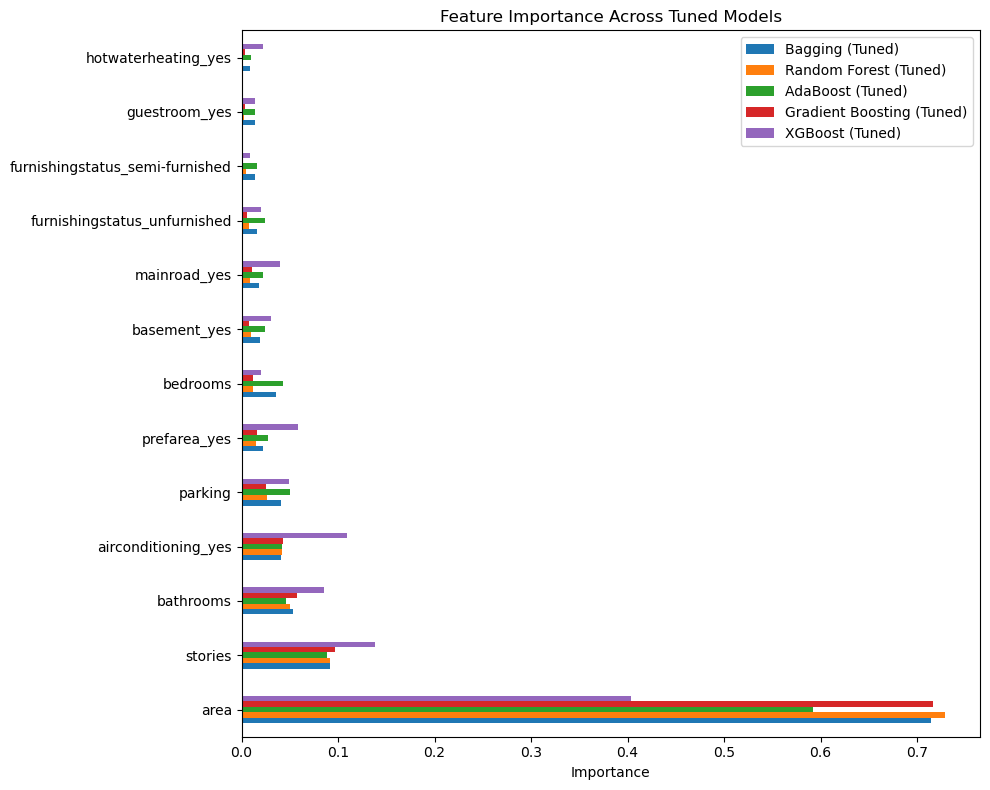

In [224]:
# Bagging's max_features setting means each tree only sees a random subset of columns, so we
# scatter each tree's importances back into the full 13-feature space using estimators_features_
n_features = X_train.shape[1]
importance_sum = np.zeros(n_features)
importance_count = np.zeros(n_features)
for est, feat_idx in zip(bag_tuned.estimators_, bag_tuned.estimators_features_):
    importance_sum[feat_idx] += est.feature_importances_
    importance_count[feat_idx] += 1
bagging_importances = np.divide(
    importance_sum, importance_count, out=np.zeros(n_features), where=importance_count > 0
)

all_importances = {
    'Bagging (Tuned)': bagging_importances,
    'Random Forest (Tuned)': rf_tuned.feature_importances_,
    'AdaBoost (Tuned)': ada_tuned.feature_importances_,
    'Gradient Boosting (Tuned)': gb_tuned.feature_importances_,
    'XGBoost (Tuned)': xgb_tuned.feature_importances_,
}

# Picking the top 3 tuned models by test R2
tuned_test_r2 = {
    'Bagging (Tuned)': test_r2_bag_tuned,
    'Random Forest (Tuned)': test_r2_rf_tuned,
    'AdaBoost (Tuned)': test_r2_ada_tuned,
    'Gradient Boosting (Tuned)': test_r2_gb_tuned,
    'XGBoost (Tuned)': test_r2_xgb_tuned,
}
top_3_models = sorted(tuned_test_r2, key=tuned_test_r2.get, reverse=True)[:3]
print("Top 3 models by test R2:", top_3_models)

importance_df = pd.DataFrame(
    {name: all_importances[name] for name in top_3_models}, index=X_train.columns
)
# sort_values(ascending=True) here so the largest bar ends up at the TOP of the barh plot
importance_df = importance_df.sort_values(top_3_models[0], ascending=True)

importance_df.plot(kind='barh', figsize=(10, 8))
plt.title('Feature Importance — Top 3 Models by Test R2 (Descending)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

`area` and `bathrooms` remain consistently among the most important features across the top 3 performing models, exactly matching what we saw in the Linear Regression and Regularization case studies on this same data. Tuning changed how well each model performs, but not which features actually drive price.

## <font color="brown"> Conclusion

* **Bagging** and **Random Forest** both overfit noticeably with default settings, their trees are grown fully by default. Tuning `max_depth`/`min_samples_leaf` (via `RandomizedSearchCV`) closes most of that gap without giving up test performance.
* **AdaBoost** underfits by default, its weak learners are too shallow for this data. Tuning lets the search pick deeper base trees, substantially improving both train and test R2.
* **Gradient Boosting** was already well-balanced with default settings, and tuning only improves it a little further.
* **XGBoost** overfits the most severely of all with default settings, but has the most to gain from tuning: once its regularization parameters (`reg_alpha`, `reg_lambda`, `subsample`, `colsample_bytree`) are properly searched instead of left at default, its train-test gap shrinks dramatically and it becomes one of the strongest models here.
* **`RandomizedSearchCV` vs `GridSearchCV`**: with several continuous hyperparameters to tune at once (learning rate, subsample ratios, regularization strengths), trying every combination with `GridSearchCV` would be far too slow. Randomly sampling a fixed number of combinations, as `RandomizedSearchCV` does, gets us most of the benefit in a fraction of the time.
* Across every model, tuned or not, **`area` and `bathrooms`** remain the strongest, most consistent predictors of price.
* For deployment, the **tuned XGBoost** or **tuned Gradient Boosting** model is the strongest choice here, both reach the best test R2 (~0.80) while keeping a healthy, non-overfit train-test gap.